#### Data Explore "Annual Car Population by Make" from data.gov.sg

In [2]:
import pandas as pd

df = pd.read_csv("AnnualCarPopulationbyMake.csv")

print(df.tail())

      year      make fuel_type  number
1938  2024  WOLSELEY    Petrol     2.0
1939  2024    WULING    Petrol     NaN
1940  2024     XPENG  Electric   336.0
1941  2024     ZEEKR  Electric    99.0
1942  2024     ZOTYE    Petrol     1.0


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1943 entries, 0 to 1942
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   year       1943 non-null   int64  
 1   make       1943 non-null   object 
 2   fuel_type  682 non-null    object 
 3   number     1894 non-null   float64
dtypes: float64(1), int64(1), object(2)
memory usage: 60.8+ KB


In [4]:
df.describe(include='object')

,make,fuel_type
count,1943,682
unique,136,8
top,MERCEDES BENZ,Petrol
freq,41,346


In [5]:
df["year"]

0       2005
1       2005
2       2005
3       2005
4       2005
        ... 
1938    2024
1939    2024
1940    2024
1941    2024
1942    2024
Name: year, Length: 1943, dtype: int64

In [6]:
df["fuel_type"]

0            NaN
1            NaN
2            NaN
3            NaN
4            NaN
          ...   
1938      Petrol
1939      Petrol
1940    Electric
1941    Electric
1942      Petrol
Name: fuel_type, Length: 1943, dtype: object

In [7]:
# Count all fuel type from YR2022 to YR2024

count_all = df["fuel_type"].value_counts()

print("=== Vehicle Count by Fuel Type (2022–2024) ===")
print(count_all)

=== Vehicle Count by Fuel Type (2022–2024) ===
fuel_type
Petrol                       346
Diesel                        96
Electric                      93
Petrol-Electric               66
Petrol-Electric (Plug-In)     46
Petrol-CNG                    18
Diesel-Electric               14
Diesel-Electric (Plug-In)      3
Name: count, dtype: int64


In [8]:
# Take note for EV, it includes "Petrol-Electric (Plug-In)", "Electric" and "Diesel-Electric (Plug-In)" 
# The classification of fuel type starts from YR2022 onwards.

df["fuel_type"].unique()

array([nan, 'Petrol', 'Diesel', 'Petrol-Electric',
       'Petrol-Electric (Plug-In)', 'Electric', 'Diesel-Electric',
       'Petrol-CNG', 'Diesel-Electric (Plug-In)'], dtype=object)

In [9]:
# Check number of fuel_type: "Diesel-Electric (Plug-In)", not popular, basically it can be ignored.

ev_diesel_by_year = (
    df[df["fuel_type"] == "Diesel-Electric (Plug-In)"] 
    .groupby("year")["number"]
    .sum()
    .astype(int)
    .reset_index(name="count")
)

print(ev_diesel_by_year)

   year  count
0  2022      1
1  2023      1
2  2024      1


In [10]:
# Define EV and Non-EV in SG

ev_df = df[
    df["fuel_type"].isin([
        "Electric",
        "Petrol-Electric (Plug-In)",
        "Diesel-Electric (Plug-In)"
    ])
]

n_ev_df = df[
    df["fuel_type"].isin([
        "Petrol",
        "Diesel",
        "Petrol-Electric",
        "Diesel-Electric",
        "Petrol-CNG"
    ])
]

print(ev_df)
print(n_ev_df)
print()

      year        make                  fuel_type  number
1271  2022        AUDI  Petrol-Electric (Plug-In)    14.0
1272  2022        AUDI                   Electric   163.0
1280  2022      B.M.W.  Petrol-Electric (Plug-In)   511.0
1281  2022      B.M.W.                   Electric   636.0
1285  2022     BENTLEY  Petrol-Electric (Plug-In)     2.0
...    ...         ...                        ...     ...
1932  2024  VOLKSWAGEN                   Electric   200.0
1936  2024       VOLVO  Petrol-Electric (Plug-In)   173.0
1937  2024       VOLVO                   Electric   541.0
1940  2024       XPENG                   Electric   336.0
1941  2024       ZEEKR                   Electric    99.0

[142 rows x 4 columns]
      year        make        fuel_type  number
1261  2022  ALFA ROMEO           Petrol   457.0
1262  2022      ALPINA           Petrol    51.0
1263  2022      ALPINA           Diesel    20.0
1264  2022      ALPINE           Petrol    42.0
1265  2022       ALVIS           Petrol 

In [11]:
# Count the no. of EV and Non-EV by year

ev_by_year = (
     ev_df   # fuel_type: Electric, Petrol/Diesel-Electric (Plug-In)
    .groupby("year")["number"]
    .sum()
    .astype(int)
    .reset_index(name="count")
)
n_ev_by_year = (
     n_ev_df   # fuel_type: Petrol/Petrol-Electric/Petrol-CNG, Diesel/Diesel-Electric
    .groupby("year")["number"]
    .sum()
    .astype(int)
    .reset_index(name="count")
)

ev_non_ev_by_year = pd.merge(
    ev_by_year,
    n_ev_by_year,
    on="year"
).fillna(0)

print("          EV    &  Non-EV:")
print(ev_non_ev_by_year)

          EV    &  Non-EV:
   year  count_x  count_y
0  2022     7674   645290
1  2023    13384   640384
2  2024    27904   632435


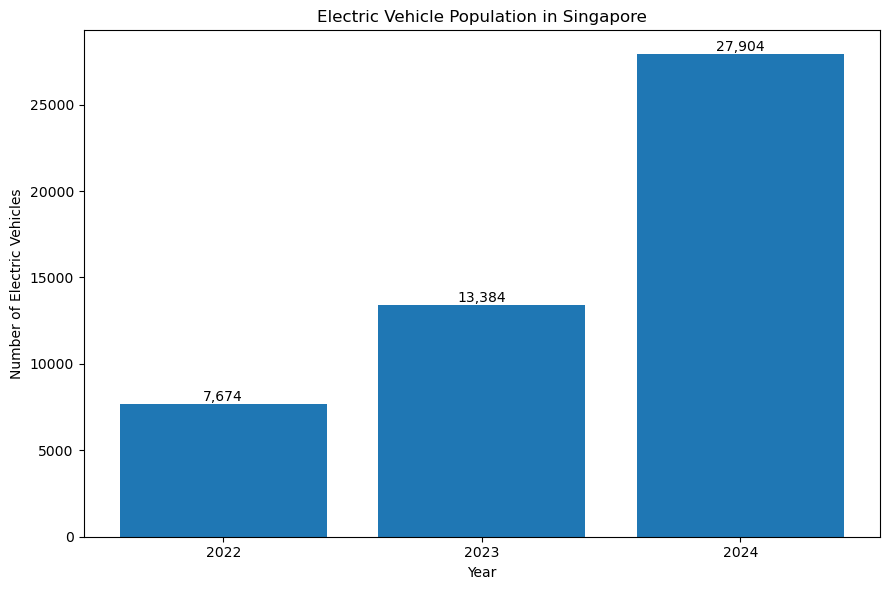

In [12]:
# Plot the bar chart

import matplotlib.pyplot as plt

ev = (
    ev_df
    .groupby("year")["number"]
    .sum()
    .reset_index()
)

plt.figure(figsize=(9, 6))

bars = plt.bar(
    ev["year"].astype(str),
    ev["number"]
)

plt.xlabel("Year")
plt.ylabel("Number of Electric Vehicles")
plt.title("Electric Vehicle Population in Singapore")

# Add values on top of bars
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height,
        f"{int(height):,}",
        ha="center",
        va="bottom"
    )

plt.tight_layout()
plt.show()

In [13]:
# Find top 5 car make for EV

top5_ev_each_year = (
    df[df["fuel_type"].isin(["Electric", "Petrol-Electric (Plug-In)", "Diesel-Electric (Plug-In)"])]
    .groupby(["year", "make"])["number"]
    .sum()
    .reset_index(name="ev_vehicles")
    .sort_values(["year", "ev_vehicles"], ascending=[True, False])
    .groupby("year")
    .head(5)
)

print(top5_ev_each_year)

     year           make  ev_vehicles
28   2022          TESLA       1840.0
1    2022         B.M.W.       1147.0
4    2022            BYD        984.0
3    2022        BLUECAR        791.0
16   2022  MERCEDES BENZ        754.0
65   2023          TESLA       2780.0
36   2023            BYD       2399.0
33   2023         B.M.W.       1938.0
52   2023  MERCEDES BENZ       1402.0
43   2023        HYUNDAI       1192.0
73   2024            BYD       8567.0
109  2024          TESLA       5163.0
70   2024         B.M.W.       3570.0
94   2024  MERCEDES BENZ       1924.0
83   2024        HYUNDAI       1898.0


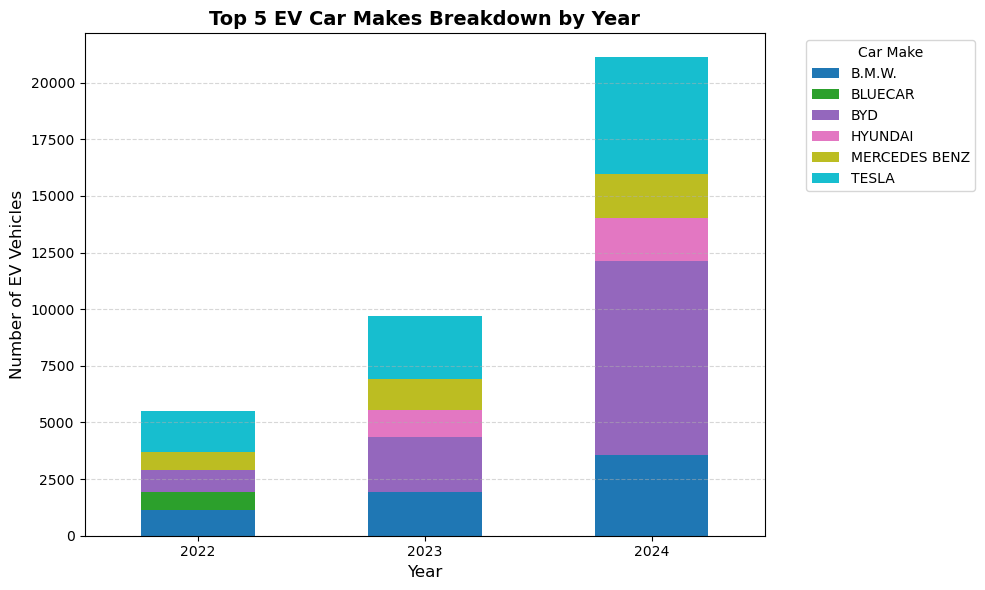

In [42]:
import matplotlib.pyplot as plt

# Pivot the data so years are rows and makes are columns
pivot_df = top5_ev_each_year.pivot(index="year", columns="make", values="ev_vehicles")

# Plot stacked bars
pivot_df.plot(kind="bar", stacked=True, figsize=(10, 6), colormap="tab10")

plt.title("Top 5 EV Car Makes Breakdown by Year", fontsize=14, fontweight='bold')
plt.xlabel("Year", fontsize=12)
plt.ylabel("Number of EV Vehicles", fontsize=12)
plt.xticks(rotation=0)  # Keeps year labels horizontal

plt.legend(title="Car Make", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(axis='y', linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()


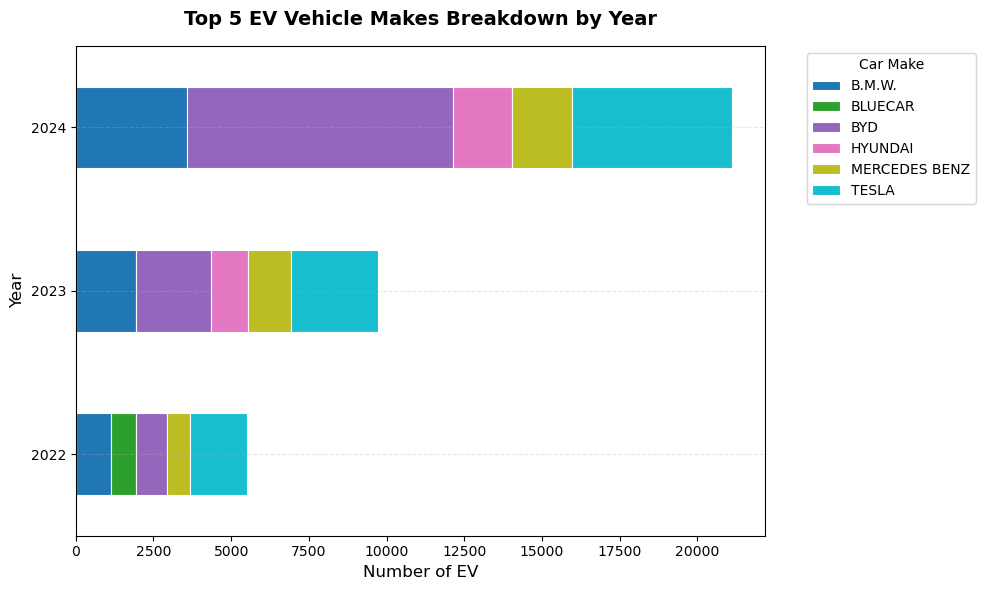

In [41]:
import matplotlib.pyplot as plt

# 1. Pivot the data so years are on the X-axis (index) and makes are stacked
pivot_df = top5_ev_each_year.pivot(index="year", columns="make", values="ev_vehicles")

# 2. Plot as a vertical stacked bar chart using a dark color palette ("magma")
ax = pivot_df.plot(
    kind="barh", 
    stacked=True, 
    figsize=(10, 6), 
    colormap="tab10",  # Modern dark theme palette
    edgecolor="white",  # Adds a crisp border between stacked segments
    linewidth=0.8
)

# Formatting the chart
plt.title("Top 5 EV Vehicle Makes Breakdown by Year", fontsize=14, fontweight='bold', pad=15)
plt.xlabel("Number of EV", fontsize=12)
plt.ylabel("Year", fontsize=12)

# Keep the year labels vertical/upright
plt.xticks(rotation=0)  

# Place the dark-themed legend safely outside the graph area
plt.legend(title="Car Make", bbox_to_anchor=(1.05, 1), loc='upper left', frameon=True)

# Clean background lines
plt.grid(axis='y', linestyle="--", alpha=0.3)
plt.tight_layout()

plt.show()
